In [1]:
import pandas as pd


dataset = pd.read_csv("../curated_dataset.csv")
dataset

,Unnamed: 0,Sequence,SMILES,Binding,Enzyme ID,Substrate ID,Publication,Validated,RHEA_ID,EC number,reaction_SMILES
0,0,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,C(C(=O)O)N,0.0,P00509,compound_aminotransferase_dataset 1,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN
1,1,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,C[C@@H](C(=O)O)N,1.0,P00509,compound_aminotransferase_dataset 2,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN
2,2,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,CC(C)[C@@H](C(=O)O)N,0.0,P00509,compound_aminotransferase_dataset 3,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN
3,3,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,CC(C)C[C@@H](C(=O)O)N,1.0,P00509,compound_aminotransferase_dataset 4,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN
4,4,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,CC[C@H](C)[C@@H](C(=O)O)N,0.0,P00509,compound_aminotransferase_dataset 5,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
73225,76466,MKYRAVTLESFGYQLAPVVVSTSDLEARLEPLYRQLRIAPGQLQAM...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Pelobacter_propionicus,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN
73226,76467,MAFLSVNNVEIVGLAAAVPKNVETLDNLEFFAPGEAEKVMALTGIK...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Bacteroides_luti,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN
73227,76468,MSAPRYSQVSAVAVRLPDEDLTTPELEELLAERNPRVDVPRGLIER...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Nonomuraea_candida,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN
73228,76469,MRYQRVFINKIAYELPKEKVATSFLEEQLTDVYQELGIPLGQVEAL...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Legionella_brunensis,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN


In [2]:
import os
import pandas as pd
import subprocess
from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolDescriptors
from rdkit.DataStructs import BulkTanimotoSimilarity

def generate_fingerprints(smiles_list, radius=2, nBits=1024):
    fps = []
    for s in smiles_list:
        mol = Chem.MolFromSmiles(s)
        if mol:
            fps.append(rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits))
        else:
            fps.append(None)
    return fps


In [3]:
import numpy as np

def compute_similarity(test_fps, train_fps):
    matrix = []
    valid_train_fps = [fp for fp in train_fps if fp is not None]

    valid_train_indices = [i for i, fp in enumerate(train_fps) if fp is not None]

    for tfp in test_fps:
        if tfp is None:
            matrix.append([0.0] * len(valid_train_fps))
        else:
            similarities = BulkTanimotoSimilarity(tfp, valid_train_fps)
            full_scores = [0.0] * len(train_fps)
            for i, score in zip(valid_train_indices, similarities):
                full_scores[i] = score

            matrix.append(max(full_scores))
            # matrix.append(full_scores)

    return np.array(matrix)

import numpy as np

def compute_similarity_and_remove(test_fps, test_ids: set, train_fps, threshold=0.7):
    matrix = []
    valid_train_fps = [fp for fp in train_fps if fp is not None]

    valid_train_indices = [i for i, fp in enumerate(train_fps) if fp is not None]
    test_ids_list = list(test_ids)
    j_to_remove = []
    for j, tfp in enumerate(test_fps):
        if tfp is None:
            matrix.append([0.0] * len(valid_train_fps))
        else:
            similarities = BulkTanimotoSimilarity(tfp, valid_train_fps)
            full_scores = [0.0] * len(train_fps)
            for i, score in zip(valid_train_indices, similarities):
                full_scores[i] = score
                if score >= threshold:
                    j_to_remove.append(j)

            matrix.append(max(full_scores))
    
    test_ids = [id_ for f, id_ in enumerate(test_ids_list) if f not in j_to_remove]
    test_fps = [fp for f, fp in enumerate(test_fps) if f not in j_to_remove]

    return test_ids, test_fps, np.array(matrix)

/tmp/ipykernel_4147144/629595460.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
/tmp/ipykernel_4147144/629595460.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
/tmp/ipykernel_4147144/629595460.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_dataset.drop_duplicates(subset=["Substr

2412 275 49


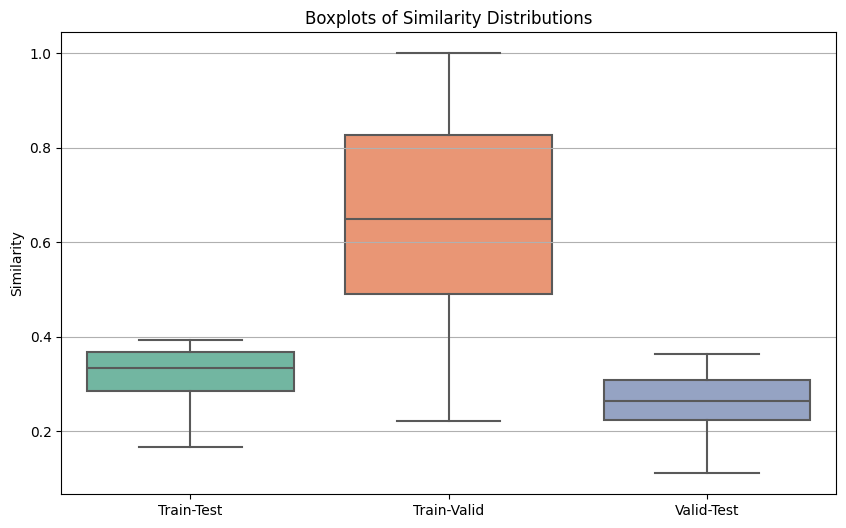

In [5]:
from plants_sm.io.pickle import read_pickle

compounds_split = read_pickle("splits_compounds_04.pkl")
train_ids = compounds_split[0][0]
test_ids = compounds_split[0][2]
valid_ids = compounds_split[0][1]

train_dataset = dataset[dataset["Substrate ID"].isin(train_ids)]
train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
train_ids = train_dataset["Substrate ID"].tolist()
train_smiles = train_dataset["SMILES"].tolist()
test_dataset = dataset[dataset["Substrate ID"].isin(test_ids)]
test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
test_ids = test_dataset["Substrate ID"].tolist()
test_smiles = test_dataset["SMILES"].tolist()
valid_dataset = dataset[dataset["Substrate ID"].isin(valid_ids)]
valid_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
valid_ids = valid_dataset["Substrate ID"].tolist()
valid_smiles = valid_dataset["SMILES"].tolist()

train_fps = generate_fingerprints(train_smiles)
test_fps = generate_fingerprints(test_smiles)
valid_fps = generate_fingerprints(valid_smiles)

test_ids, test_fps, train_test_similarity = compute_similarity_and_remove(test_fps, test_ids, train_fps, 0.40)
# valid_ids, valid_fps, train_valid_similarity = compute_similarity_and_remove(valid_fps, set(valid_ids), train_fps, 0.2)
test_ids, test_fps, valid_test_similarity = compute_similarity_and_remove(test_fps, test_ids, valid_fps, 0.40)

train_dataset = dataset[dataset["Substrate ID"].isin(train_ids)]
train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
train_ids = train_dataset["Substrate ID"].tolist()
train_smiles = train_dataset["SMILES"].tolist()
test_dataset = dataset[dataset["Substrate ID"].isin(test_ids)]
test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
test_ids = test_dataset["Substrate ID"].tolist()
test_smiles = test_dataset["SMILES"].tolist()
valid_dataset = dataset[dataset["Substrate ID"].isin(valid_ids)]
valid_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
valid_ids = valid_dataset["Substrate ID"].tolist()
valid_smiles = valid_dataset["SMILES"].tolist()

train_fps = generate_fingerprints(train_smiles)
test_fps = generate_fingerprints(test_smiles)
valid_fps = generate_fingerprints(valid_smiles)

train_test_similarity = compute_similarity(test_fps, train_fps)
train_valid_similarity = compute_similarity(valid_fps, train_fps)
valid_test_similarity = compute_similarity(test_fps, valid_fps)

from plants_sm.io.pickle import read_pickle, write_pickle
print(len(train_ids), len(valid_ids), len(test_ids))

write_pickle("splits_compounds_04_corrected.pkl", [(train_ids, valid_ids, test_ids)])

import matplotlib.pyplot as plt
import seaborn as sns

data = [
    train_test_similarity,
    train_valid_similarity,
    valid_test_similarity
]

# Plotting the boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, palette="Set2")
plt.title('Boxplots of Similarity Distributions')
plt.ylabel('Similarity')
plt.xticks([0, 1, 2], ['Train-Test', 'Train-Valid', 'Valid-Test'])
plt.grid(axis='y')
plt.savefig('boxplots_similarity_40_2.png', format='PNG', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
dataset = pd.read_csv("../curated_dataset.csv")

/tmp/ipykernel_2574964/38788760.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
/tmp/ipykernel_2574964/38788760.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
/tmp/ipykernel_2574964/38788760.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_dataset.drop_duplicates(subset=["Substrate

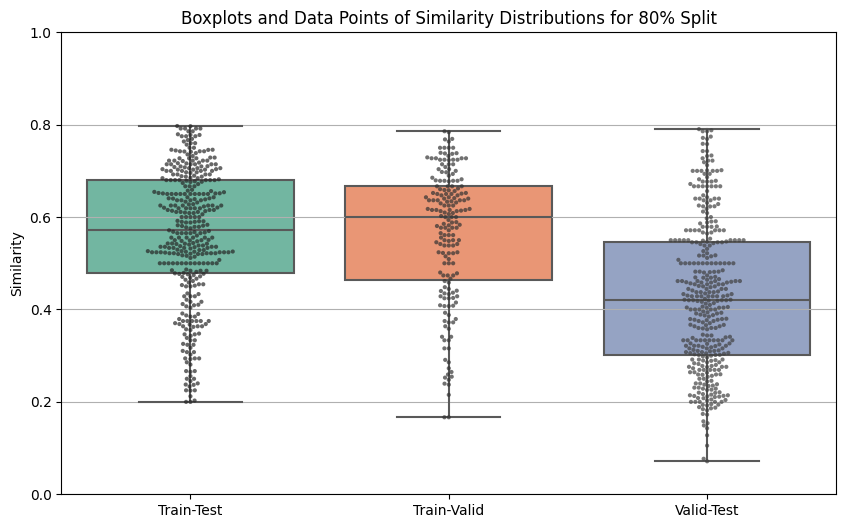

In [4]:
from plants_sm.io.pickle import read_pickle

compounds_split = read_pickle("splits_compounds_08.pkl")
train_ids = compounds_split[0][0]
test_ids = compounds_split[0][2]
valid_ids = compounds_split[0][1]

train_dataset = dataset[dataset["Substrate ID"].isin(train_ids)]
train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
train_ids = train_dataset["Substrate ID"].tolist()
train_smiles = train_dataset["SMILES"].tolist()
test_dataset = dataset[dataset["Substrate ID"].isin(test_ids)]
test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
test_ids = test_dataset["Substrate ID"].tolist()
test_smiles = test_dataset["SMILES"].tolist()
valid_dataset = dataset[dataset["Substrate ID"].isin(valid_ids)]
valid_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
valid_ids = valid_dataset["Substrate ID"].tolist()
valid_smiles = valid_dataset["SMILES"].tolist()

train_fps = generate_fingerprints(train_smiles)
test_fps = generate_fingerprints(test_smiles)
valid_fps = generate_fingerprints(valid_smiles)

train_test_similarity = compute_similarity(test_fps, train_fps)
train_valid_similarity = compute_similarity(valid_fps, train_fps)
valid_test_similarity = compute_similarity(test_fps, valid_fps)

from plants_sm.io.pickle import read_pickle, write_pickle

import matplotlib.pyplot as plt
import seaborn as sns

data = [
    train_test_similarity,
    train_valid_similarity,
    valid_test_similarity
]

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' is a DataFrame or array with 3 columns for Train-Test, Train-Valid, Valid-Test similarities
plt.figure(figsize=(10, 6))

# Draw boxplots
sns.boxplot(data=data, palette="Set2")

# Draw data points (using swarmplot for better visibility)
sns.swarmplot(data=data, color=".25", alpha=0.7,size=3)

plt.title('Boxplots and Data Points of Similarity Distributions for 80% Split')
plt.ylabel('Similarity')
plt.ylim(0, 1)
plt.xticks([0, 1, 2], ['Train-Test', 'Train-Valid', 'Valid-Test'])
plt.grid(axis='y')
plt.savefig('boxplots_with_points_80.png', format='PNG', dpi=200, bbox_inches='tight', transparent=True)
plt.show()


/tmp/ipykernel_2574964/1628555030.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
/tmp/ipykernel_2574964/1628555030.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
/tmp/ipykernel_2574964/1628555030.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_dataset.drop_duplicates(subset=["Sub

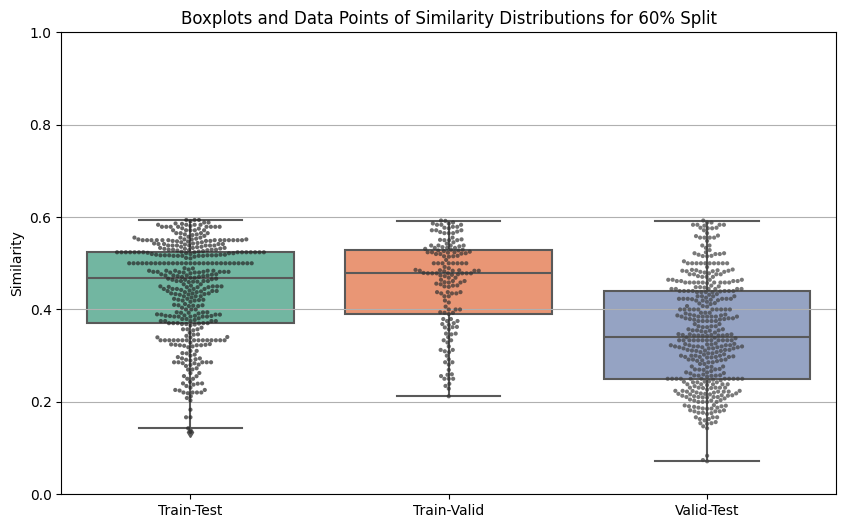

In [5]:
from plants_sm.io.pickle import read_pickle

compounds_split = read_pickle("splits_compounds_06.pkl")
train_ids = compounds_split[0][0]
test_ids = compounds_split[0][2]
valid_ids = compounds_split[0][1]

train_dataset = dataset[dataset["Substrate ID"].isin(train_ids)]
train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
train_ids = train_dataset["Substrate ID"].tolist()
train_smiles = train_dataset["SMILES"].tolist()
test_dataset = dataset[dataset["Substrate ID"].isin(test_ids)]
test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
test_ids = test_dataset["Substrate ID"].tolist()
test_smiles = test_dataset["SMILES"].tolist()
valid_dataset = dataset[dataset["Substrate ID"].isin(valid_ids)]
valid_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
valid_ids = valid_dataset["Substrate ID"].tolist()
valid_smiles = valid_dataset["SMILES"].tolist()

train_fps = generate_fingerprints(train_smiles)
test_fps = generate_fingerprints(test_smiles)
valid_fps = generate_fingerprints(valid_smiles)

train_test_similarity = compute_similarity(test_fps, train_fps)
train_valid_similarity = compute_similarity(valid_fps, train_fps)
valid_test_similarity = compute_similarity(test_fps, valid_fps)

from plants_sm.io.pickle import read_pickle, write_pickle

import matplotlib.pyplot as plt
import seaborn as sns

data = [
    train_test_similarity,
    train_valid_similarity,
    valid_test_similarity
]

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' is a DataFrame or array with 3 columns for Train-Test, Train-Valid, Valid-Test similarities
plt.figure(figsize=(10, 6))

# Draw boxplots
sns.boxplot(data=data, palette="Set2")

# Draw data points (using swarmplot for better visibility)
sns.swarmplot(data=data, color=".25", alpha=0.7, size=3)

plt.title('Boxplots and Data Points of Similarity Distributions for 60% Split')
plt.ylabel('Similarity')
plt.ylim(0, 1)
plt.xticks([0, 1, 2], ['Train-Test', 'Train-Valid', 'Valid-Test'])
plt.grid(axis='y')
plt.savefig('boxplots_with_points_60.png', format='PNG', dpi=200, bbox_inches='tight', transparent=True)
plt.show()


In [6]:
compounds_split = read_pickle("splits_compounds_04_corrected.pkl")
train_ids = compounds_split[0][0]
test_ids = compounds_split[0][2]
valid_ids = compounds_split[0][1]
print(len(train_ids), len(valid_ids), len(test_ids))

2412 275 49


In [14]:
compounds_split = read_pickle("splits_compounds_04.pkl")
train_ids = compounds_split[0][0]
test_ids = compounds_split[0][2]
valid_ids = compounds_split[0][1]
print(len(train_ids), len(valid_ids), len(test_ids))

2412 275 503


/tmp/ipykernel_2574964/3605424753.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
/tmp/ipykernel_2574964/3605424753.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
/tmp/ipykernel_2574964/3605424753.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_dataset.drop_duplicates(subset=["Sub

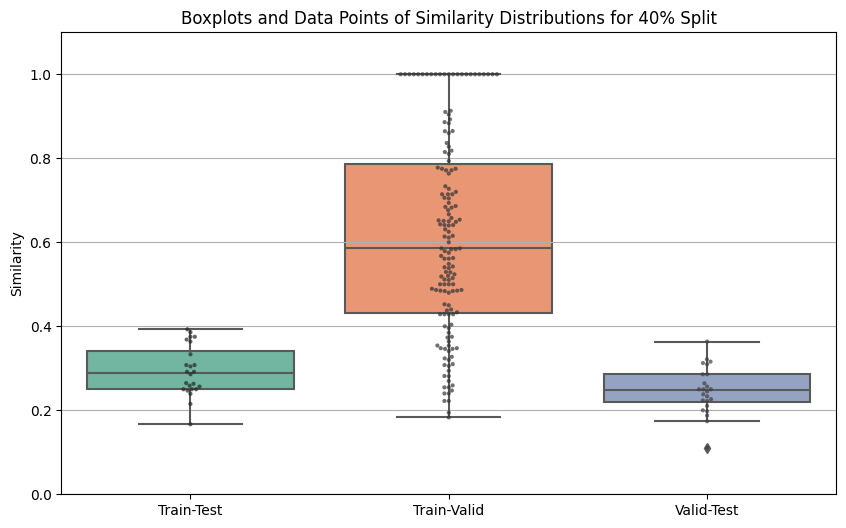

In [7]:
from plants_sm.io.pickle import read_pickle

compounds_split = read_pickle("splits_compounds_04_corrected.pkl")
train_ids = compounds_split[0][0]
test_ids = compounds_split[0][2]
valid_ids = compounds_split[0][1]

train_dataset = dataset[dataset["Substrate ID"].isin(train_ids)]
train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
train_ids = train_dataset["Substrate ID"].tolist()
train_smiles = train_dataset["SMILES"].tolist()
test_dataset = dataset[dataset["Substrate ID"].isin(test_ids)]
test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
test_ids = test_dataset["Substrate ID"].tolist()
test_smiles = test_dataset["SMILES"].tolist()
valid_dataset = dataset[dataset["Substrate ID"].isin(valid_ids)]
valid_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
valid_ids = valid_dataset["Substrate ID"].tolist()
valid_smiles = valid_dataset["SMILES"].tolist()

train_fps = generate_fingerprints(train_smiles)
test_fps = generate_fingerprints(test_smiles)
valid_fps = generate_fingerprints(valid_smiles)

train_test_similarity = compute_similarity(test_fps, train_fps)
train_valid_similarity = compute_similarity(valid_fps, train_fps)
valid_test_similarity = compute_similarity(test_fps, valid_fps)

from plants_sm.io.pickle import read_pickle, write_pickle

import matplotlib.pyplot as plt
import seaborn as sns

data = [
    train_test_similarity,
    train_valid_similarity,
    valid_test_similarity
]

# Assuming 'data' is a DataFrame or array with 3 columns for Train-Test, Train-Valid, Valid-Test similarities
plt.figure(figsize=(10, 6))

# Draw boxplots
sns.boxplot(data=data, palette="Set2")

# Draw data points (using swarmplot for better visibility)
sns.swarmplot(data=data, color=".25", alpha=0.7, size=3)

plt.title('Boxplots and Data Points of Similarity Distributions for 40% Split')
plt.ylabel('Similarity')
plt.ylim(0, 1.1)
plt.xticks([0, 1, 2], ['Train-Test', 'Train-Valid', 'Valid-Test'])
plt.grid(axis='y')
plt.savefig('boxplots_with_points_40.png', format='PNG', dpi=200, bbox_inches='tight', transparent=True)
plt.show()

/tmp/ipykernel_2574964/2439308740.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
/tmp/ipykernel_2574964/2439308740.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
/tmp/ipykernel_2574964/2439308740.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_dataset.drop_duplicates(subset=["Sub

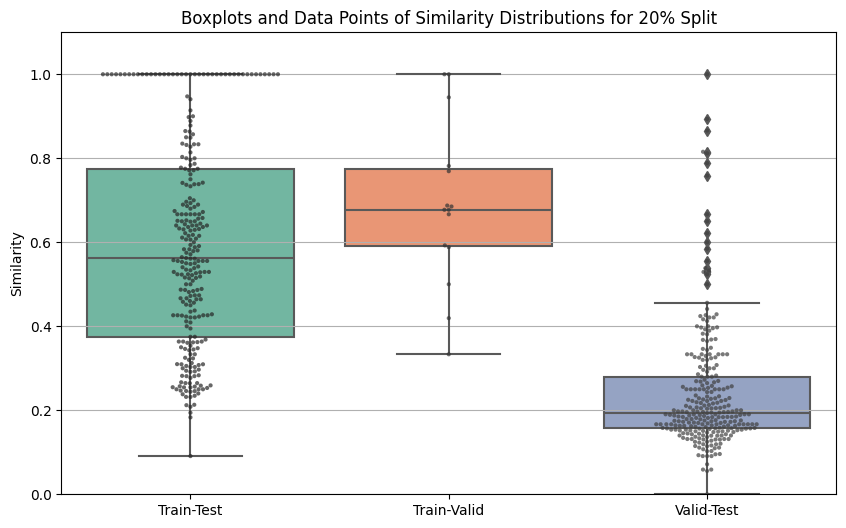

In [8]:
from plants_sm.io.pickle import read_pickle

compounds_split = read_pickle("splits_compounds_02.pkl")
train_ids = compounds_split[0][0]
test_ids = compounds_split[0][2]
valid_ids = compounds_split[0][1]

train_dataset = dataset[dataset["Substrate ID"].isin(train_ids)]
train_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
train_ids = train_dataset["Substrate ID"].tolist()
train_smiles = train_dataset["SMILES"].tolist()
test_dataset = dataset[dataset["Substrate ID"].isin(test_ids)]
test_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
test_ids = test_dataset["Substrate ID"].tolist()
test_smiles = test_dataset["SMILES"].tolist()
valid_dataset = dataset[dataset["Substrate ID"].isin(valid_ids)]
valid_dataset.drop_duplicates(subset=["Substrate ID"], inplace=True)
valid_ids = valid_dataset["Substrate ID"].tolist()
valid_smiles = valid_dataset["SMILES"].tolist()

train_fps = generate_fingerprints(train_smiles)
test_fps = generate_fingerprints(test_smiles)
valid_fps = generate_fingerprints(valid_smiles)

train_test_similarity = compute_similarity(test_fps, train_fps)
train_valid_similarity = compute_similarity(valid_fps, train_fps)
valid_test_similarity = compute_similarity(test_fps, valid_fps)

from plants_sm.io.pickle import read_pickle

import matplotlib.pyplot as plt
import seaborn as sns

data = [
    train_test_similarity,
    train_valid_similarity,
    valid_test_similarity
]

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' is a DataFrame or array with 3 columns for Train-Test, Train-Valid, Valid-Test similarities
plt.figure(figsize=(10, 6))

# Draw boxplots
sns.boxplot(data=data, palette="Set2")

# Draw data points (using swarmplot for better visibility)
sns.swarmplot(data=data, color=".25", alpha=0.7, size=3)

plt.title('Boxplots and Data Points of Similarity Distributions for 20% Split')
plt.ylabel('Similarity')
plt.ylim(0, 1.1)
plt.xticks([0, 1, 2], ['Train-Test', 'Train-Valid', 'Valid-Test'])
plt.grid(axis='y')
plt.savefig('boxplots_with_points_20.png', format='PNG', dpi=200, bbox_inches='tight', transparent=True)
plt.show()